# An Introduction to PyTorch for Remote Sensing
## Mikael Brunila<br>Geographic Information Centre (McGill)
### March 2025

## Overview: Part 1

- **A: Introduction to PyTorch** (15 min)
  - Pattern recognition problems in Remote Sensing
      - Classification
      - Object Detection
      - Segmentation
      - Change Detection
  - Deterministic approaches
  - Probabilistic approaches
  - What is PyTorch?
- **B: Case: Ship Detection with YOLOv5** (45 min)
  - 101: Loading, predicting, visualizing
  - Custom models
  - Training 

## Overview: Part 2

- **A: Model training** (15 min)
  - Deep Learning
  - Splits: Train, validate, test
  - Torch Lightning
  - Torch models and Remote Sensing: Known Challenges
      - TorchGeo
- **B: Case: Land Classification with TorchGeo** (30 min)
  - Classifying land patches from the EuroSAT dataset
  - Datasets and Datamodules
  - Models and tasks
  - Test set evaluation
- **C: Case: Predicting on new data** (15 min)
  - Loading Sentinel-2 data with PyStac (recap)
  - Predict and visualize
- **D: Hands on: Predicting on new data** (30+ min)
  - Pick a new area and replicate part C

## First...

Let's make sure all of you have the relevant notebook and files. You have two options:

1. Google Colab
2. Clone from Github

## Google Colab

Go to `https://github.com/maybemkl/gic-rs-tutorials`.

Make sure you have the relevant files on your instance. These should include:

 - A folder called "img"
 
If you do *not* have it:

1. Download it from https://www.mediafire.com/file/pst5sfdw0vj005q/img.zip/file
2. Upload it to the Google Colab

## Git Pull

Go to `https://github.com/maybemkl/gic-rs-tutorials` and follow the instructions there.

# Part 1A: Introduction to PyTorch

## Pattern recognition problems in Remote Sensing

1. **Classification** – Assigning a label to each pixel or region (e.g., land cover classification, crop type mapping).
2. **Object Detection** – Identifying and localizing objects (e.g., ship detection, vehicle tracking, wildfire detection).
3. **Segmentation** – More detailed than classification; assigns a class to each pixel while preserving object boundaries (e.g., water body segmentation, urban mapping).
4. **Change Detection** – Identifying changes over time using multi-temporal images (e.g., deforestation monitoring, urban expansion).

## Deterministic Approaches

- Rely on fixed rules, thresholds, or explicit "feature extraction".
- Often used in classical remote sensing methods.
- Examples:
    - Threshold-based classification (e.g., NDVI > 0.3 → vegetation).
    - Edge detection for segmentation.

## Probabilistic Approaches

- Model uncertainty and variations in data.
- Machine learning and deep learning.
- Examples:
    - Naive Bayes (NB) for land cover classification.
    - Deep learning-based object detection (YOLO, Faster R-CNN) that outputs confidence scores.

## What is PyTorch?

- Open-source deep learning framework
- A flexible and efficient way to build, train, and deploy machine learning models. 
- Relatively easy to use, very widespread


![](img/percentage_repo_2023.png)

*Source:* [Assembly.AI](https://www.assemblyai.com/blog/pytorch-vs-tensorflow-in-2023/)

# Part 1B: Case: Ship Detection with YOLOv5

## YOLOv5

- The [YOLO (You Only Look Once) framework](https://github.com/ultralytics/yolov5).
- Fast and light **object detection model**
- Supports training, inference, and fine-tuning with minimal setup
- Different sizes: Nano to XL
- Architecture: 
    - Backbone: CNN
    - Neck: Path Aggregation Network
    - Head: Anchor-based dense prediction head
- There are also [other YOLO models](https://docs.ultralytics.com/models/).

As always, we start by initializing libraries. `cv2` is a general purpose computer vision library that we will use for some plotting and visualization tasks. `torch` is just short for PyTorch.

In [1]:
import cv2
import matplotlib.pyplot as plt
import os
import torch

We also set our device to `cpu` when the NVIDI `cuda` interpreter isn't available. To make our results reproducible, we set a seed for all torch operations using `torch.manual_seed()`. 

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

We will download and initialize the small YOLOv5 by setting `yolov5s`. For other sizes, see the YOLOv5 [GitHub page](https://github.com/ultralytics/yolov5).

In [3]:
%%time

model = torch.hub.load(
    repo_or_dir = 'ultralytics/yolov5', 
    model = 'yolov5s',
    force_reload = True, 
    pretrained=True
)

Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /Users/mikaelbrunila/.cache/torch/hub/master.zip
YOLOv5 🚀 2025-3-3 Python-3.12.0 torch-2.2.2 CPU

Fusing layers... 
[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


CPU times: user 2.08 s, sys: 1.01 s, total: 3.09 s
Wall time: 4.1 s


Let's try the model on a simple image. This one isn't remote sensing. It's important to note that YOLOv5 isn't specificially trained on RS data.

![](img/dog.jpeg)

Okay, in order to use the model, we just have to give it a path to an image. Let's start by visualizing what it does using the built-in `show()` command.

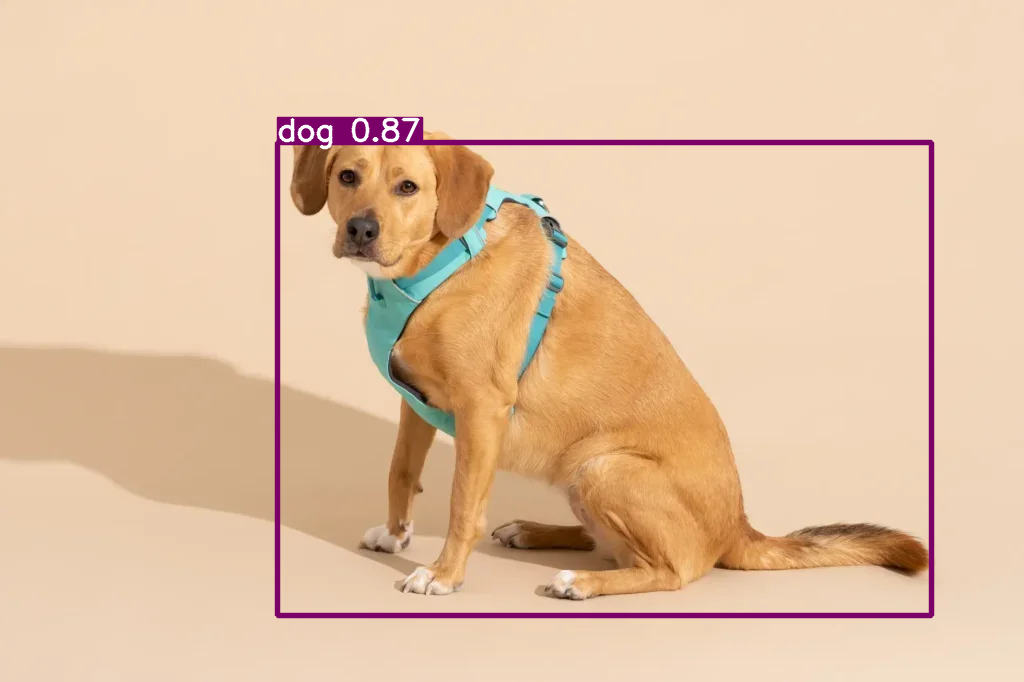

In [4]:
model('img/dog.jpeg').show()

It did great! Good dog. What about this more tricky image, with a lot of different characters.

![](img/cars_people_bear.jpg)

We run through the same motions. And it again does well!

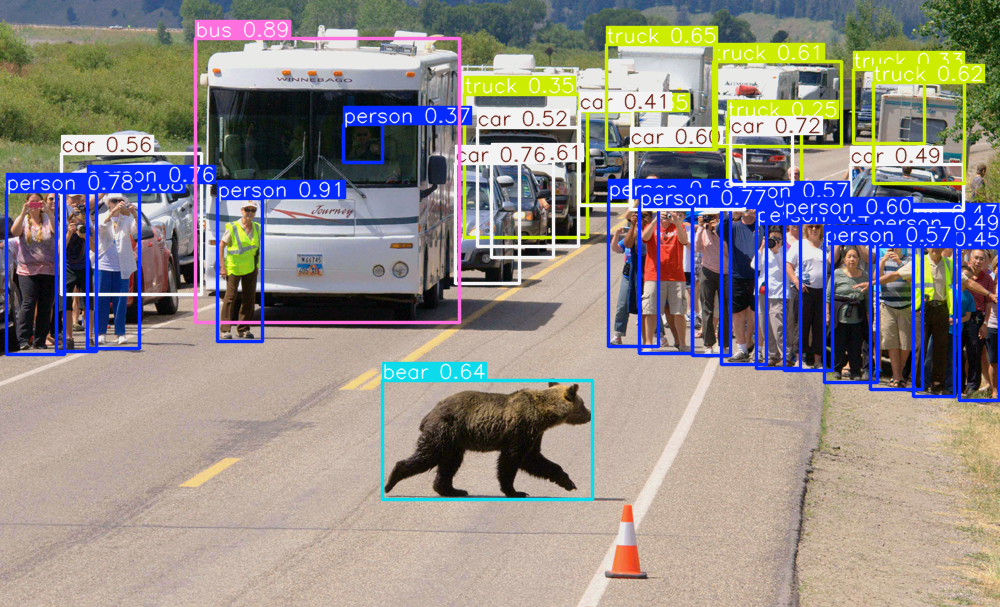

In [5]:
model('img/cars_people_bear.jpg').show()

## YOLOv5 for RS

So should we be bullish on bearish on YOLOv5 for remote sensing? Let's try it out on this image from the [ShipRSImageNet](https://github.com/zzndream/ShipRSImageNet) dataset. I will introduce it in detail below.

<img src="img/boats/000187.bmp" width="400">

We run the model on the image and... nothing happens. It doesnt' detect anything :-(

In [73]:
def resize_yolo_img(results):
    # Convert image for proper display
    img = results.render()[0]  # Get rendered image with detections
    #img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB

    # Resize output image
    scale = 0.5  # Adjust as needed (0.5 = 50% smaller)
    img_resized = cv2.resize(img, None, fx=scale, fy=scale)

    # Display with Matplotlib
    plt.figure(figsize=(6, 6))  # Control display size
    plt.imshow(img_resized)
    plt.axis("off")
    plt.show()


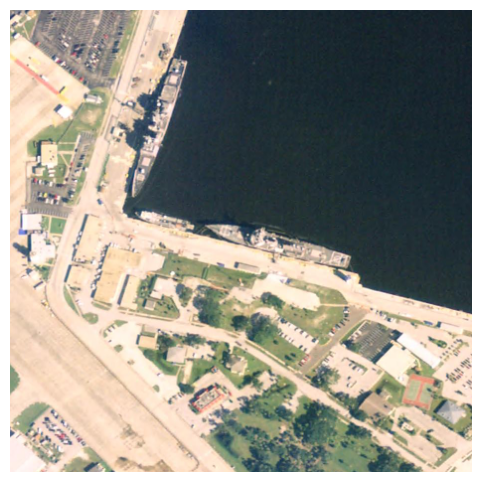

In [74]:
resize_yolo_img(model('img/boats/000187.bmp'))

Let's try it on another image, just in case.

<img src="img/boats/000244.bmp" width="400">

Well, it finds something, but... is this better? Not really.

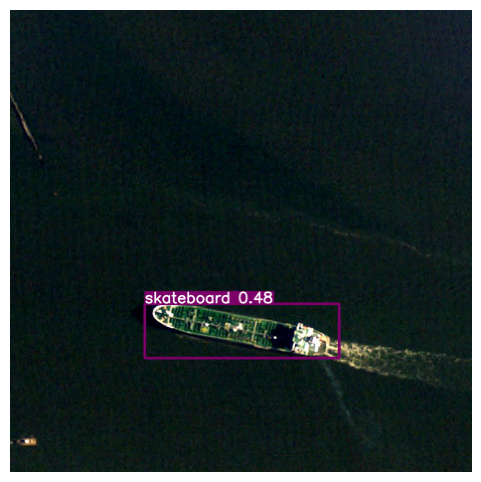

In [76]:
resize_yolo_img(model('img/boats/000244.bmp'))

## Loading a Custom YOLOv5 model

Nonetheless, YOLOv5 is one of the more popular object detection models in RS. Why is that? Well, we can finetune it using RS data, "transfering" its baseline object detection capabilities into a new domain. 

UCL based researcher [Ollie Ballinger](https://oballinger.github.io/) has done just this. We can pull his variant of YOLOv5 from GitHub  by running:

`git pull https://github.com/oballinger/yolov5_RS`

This repository has a folder called `weights` with a set of YOLOv5 models finetuned on data from different domains.

![](img/yolov5_rs_weights.png)

We will use `ships.pt` because we are trying to detect ships for relatively high-resolution data. The `.pt` is a format in which PyTorch models are saved. Each of these five files is a PyTorch model that started with the baseline YOLOv5 model and was then finetuned on specific data.

We can again use `torch.hub.load()` but we have to give it different arguments. `repo_or_dir` is now the folder that we pulled. `model` is `'custom'` and `path` is the path to our `.pt` weights. The source is `'local'`. 

In [10]:
model_rs = torch.hub.load(
    repo_or_dir = '../yolov5_rs',
    model = 'custom', 
    path='../yolov5_rs/weights/ships.pt',
    source='local'
)

YOLOv5 🚀 2025-3-3 Python-3.12.0 torch-2.2.2 CPU

Fusing layers... 
custom_YOLOv5s summary: 182 layers, 7246518 parameters, 0 gradients
Adding AutoShape... 


requirements: /usr/local/Caskroom/miniconda/base/envs/rs-torch/lib/python3.12/site-packages/requirements.txt not found, check failed.


How does the model do now?

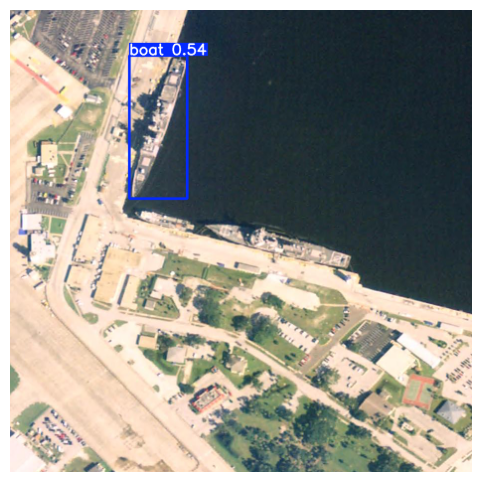

In [77]:
resize_yolo_img(model_rs('img/boats/000187.bmp'))

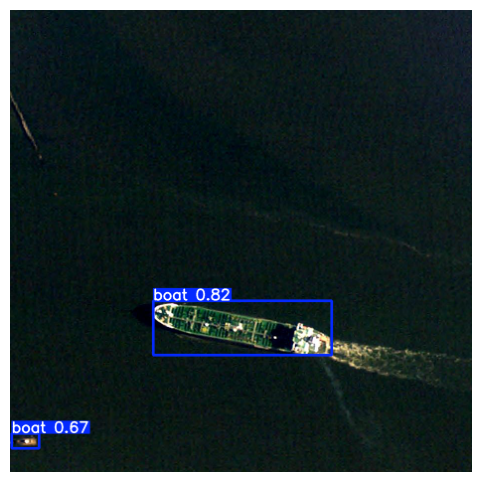

In [79]:
resize_yolo_img(model_rs('img/boats/000244.bmp'))

## Extracting labels

Okay, we have a decent model now. What if we want to do more than just look at the labels and analyze them in aggregate? How do we pull the labels from the model predictions?

This is one way:

In [13]:
yolo_rs_out = model_rs('img/boats/000244.bmp')
df = yolo_rs_out.pandas().xyxy[0]
df

,xmin,ymin,xmax,ymax,confidence,class,name
0,288.122131,585.632874,647.987671,694.306152,0.820224,0,boat
1,3.926354,852.629761,58.108963,882.328918,0.668731,0,boat


Focusing on the `boat` label, we can count the total number of boats in an image.

In [14]:
boat_count = (df['name'] == 'boat').sum()  # Count boats by label
print(f"Detected boats: {boat_count}")

Detected boats: 2


In [15]:
def get_counts_for_images(
    yolo_model, 
    label:str='boat',
                          
    path:str="img/boats"
):
    image_folder = "img/boats"
    image_paths = [os.path.join(image_folder, img) for 
                   img in os.listdir(image_folder) if img.endswith((".bmp"))]

    # Dictionary to store image paths and their boat counts
    counts = {}

    # Loop through images and detect boats
    for img_path in image_paths:
        results = yolo_model(img_path)
        df = results.pandas().xyxy[0]  # Convert results to a DataFrame
        count = (df['name'].isin([label])).sum()  # Count boats
        counts[img_path] = count

    # Sort by highest boat count and get top 16 images
    top_images = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    return top_images

In [68]:
# Create a 4x4 grid and plot the model.show() outputs
def plot_4x4_grid(images, yolo_model, label:str="Boats"):
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))

    for ax, (img_path, count) in zip(axes.flatten(), images):
        results = yolo_model(img_path)  # Run inference
        results.render()  # Apply YOLOv5 annotations to the image

        # Read the image back with annotations
        annotated_img = results.ims[0]  # YOLO stores annotated images here
        ax.imshow(annotated_img)
        ax.set_title(f"{label}: {count}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

We can scale this up with a helper function that goes over all the images in the folder `img/boats` and calculates the number of boats in each.

In [69]:
most_boats = get_counts_for_images(model_rs)[10:26]
most_boats[:3]

[('img/boats/004634.bmp', 6),
 ('img/boats/5__920_0.bmp', 5),
 ('img/boats/004713.bmp', 5)]

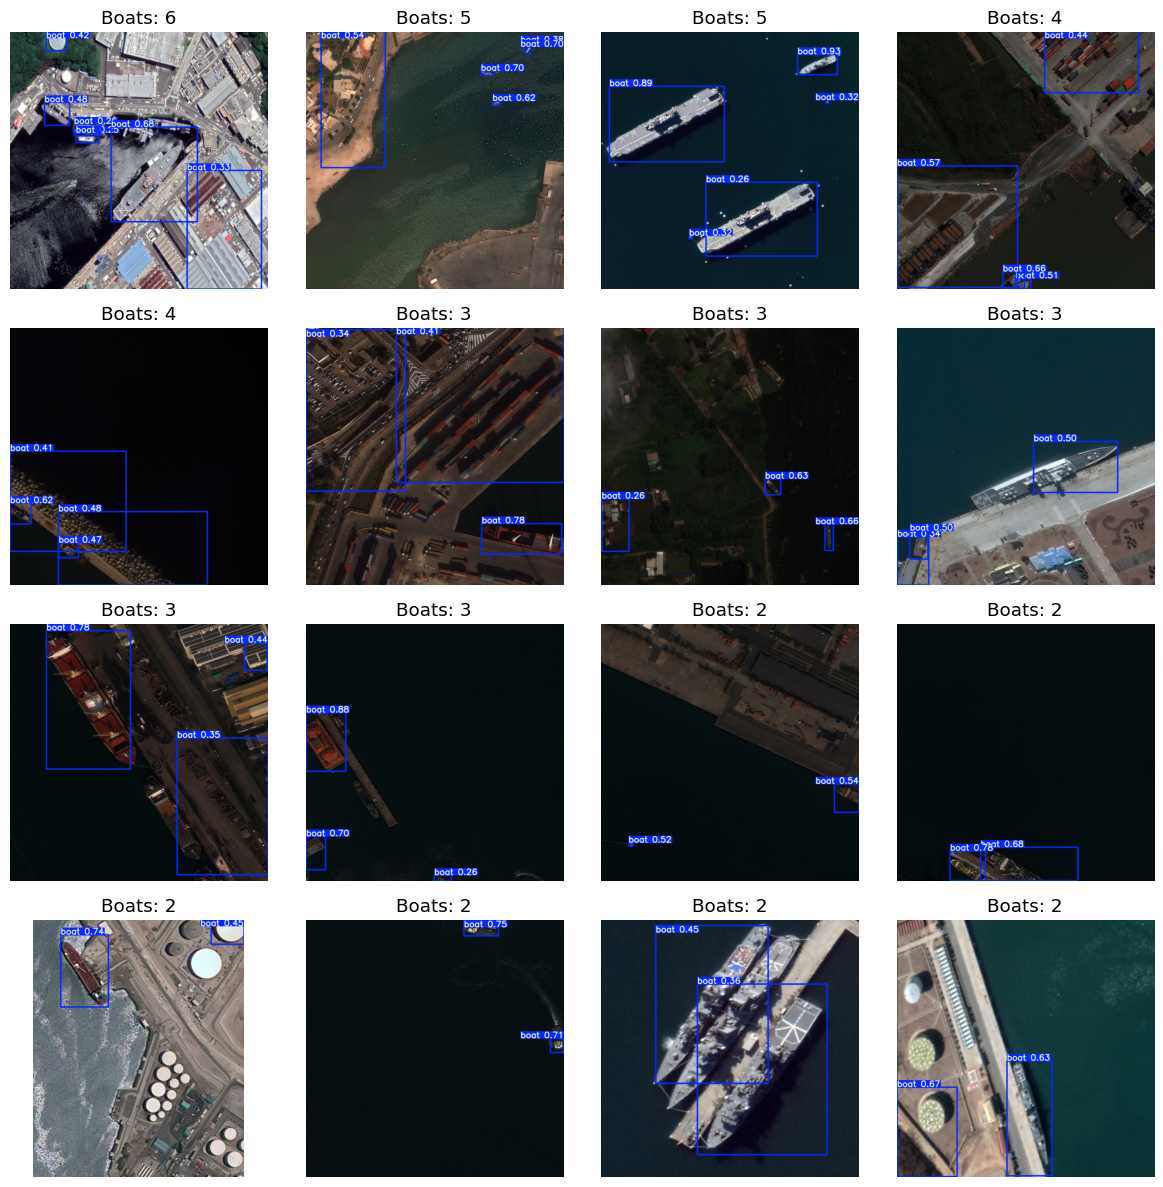

In [70]:
%matplotlib inline

plot_4x4_grid(most_boats, model_rs)

# Fine-Tuning a YOLOv5 model

## Getting granular

- While the model above was able to recognize "boats", it doesn't provide any distinction between a tugboat and an aircraft carrier.
- Moreover, we don't actually know what data was used to train these models. Their nice to play around with, but not good for reproducible scientific work!
- If we want to get more granular, we have to finetune a model ourselves.

## Data: ShipRSImageNet

- We will use a dataset called [ShipRSImageNet](https://github.com/zzndream/ShipRSImageNet)
- `"A Large-scale Fine-Grained Dataset for Ship Detection in High-Resolution Optical Remote Sensing Images"`
- Sources images from several high-res satellites and applies 50 granular labels to them

## Pull YOLOv5 from the original repo

Let's use the very baseline YOLOv5, i.e. not the RS one we were working with above. So, do something like the following:

`cd ..`<br>
`git pull https://github.com/ultralytics/yolov5`

## Get the `ShipRSImageNet` data in YOLOv5-format

YOLO requires a specific format. As luck has it, the ShipRSImageNet is available in this format. We can find it on [RoboFlow](https://universe.roboflow.com/convertvoctoyolo/shiprsimagenet/dataset/18). You can download it from there (you need a free account) or access the [temporary link I've created on Mediafire](https://www.mediafire.com/file/r9ndt237pp7u74x/ShipRSImageNet.v18i.yolov5pytorch.zip/file). Next, unzip the data and move it to the `yolov5` folder.

## Folder structure

If you look at the data, you can see it has the following organization. This is how YOLOv5 data needs to be setup:

![](img/yolo_folder_structure.png)

## Data

 I wrote a little script to go over the folders in `train`. Let's take a closer look at the images and labels there.

In [27]:
def read_yolo_paths(path, idx):
    folder = f"../yolov5/ShipRSImageNet.v18i.yolov5pytorch/train/{path}"
    files = sorted(f for f in os.listdir(folder) 
                   if os.path.isfile(
                       os.path.join(folder, f)))

    file = os.path.join(folder, files[idx])
    return file

Each image has a corresponding set of labels.

In [59]:
img_path = read_yolo_paths("images", 35)
img_path

'../yolov5/ShipRSImageNet.v18i.yolov5pytorch/train/images/000040_bmp.rf.fc044a20a77e82386d611c7ba5079e6e.jpg'

In [63]:
label_path = read_yolo_paths("labels", 35)
label_path

'../yolov5/ShipRSImageNet.v18i.yolov5pytorch/train/labels/000040_bmp.rf.fc044a20a77e82386d611c7ba5079e6e.txt'

The image in turn is a raster with width, height, and RGB colors. Notice how there are five objects of interest in this image: four ships and one peer.

In [64]:
img = cv2.imread(img_path)  # Reads as BGR
img.shape

(930, 930, 3)

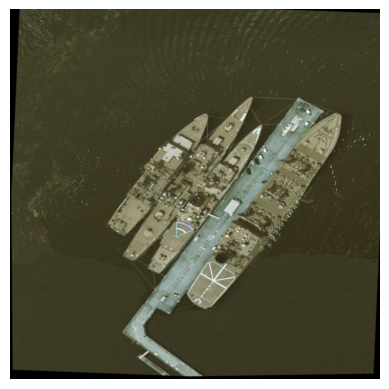

In [65]:
plt.imshow(img)
plt.axis("off")
plt.show()

If we look at the labels, we get a label for each of these objects. How would you read this output?

In [66]:
with open(label_path, "r") as f:
    labels = list()
    for line in f.readlines():
        labels.append(line)
    
labels

['28 0.4828100026648739 0.45892957217855235 0.39655739369792425 0.521783651150199\n',
 '33 0.398826431765307 0.440550660534024 0.3141550889136294 0.4036284467806823\n',
 '0 0.6924346067620234 0.5398293437917384 0.4680068269188312 0.6054051345146716\n',
 '9 0.6020651081345156 0.532815826040559 0.4972517798366511 0.6423020952067848\n',
 '14 0.5288123303485635 0.5105483546813093 0.3607544804502266 0.46653204925290875']

### Setting up the YAML

In addition to the data, we need to setup a `.yaml` file where YOLOv5 can find:

1. The paths to the training and validation data and 
2. Information on the exact labels of objects in the data.

![](img/yaml.png)

## Training the model

To train the model, run the following in the command line:

`python train.py --img 928 --batch 16 --epochs 10 --data shipsrs.yaml --weights yolov5s.pt`

Let's unpack a bit:

- `train.py` is the training script that ships with YOLOv5
- `--img 928` tells the trainer that our images are 928x928 pixels. We use this number instead of 930 because our value needs to be divisible by 32 for efficient computations.
- `--epochs 10` this tells YOLOv5 to do 10 passes over the data
- `shipsrs.yaml` has the information that YOLOv5 needs to find and read the training and validation data
- `--weights yolov5s.pt` these are the starting weights, the pre-trained model we finetune

## Training the model

Training the model on my new Mac took a couple of hours, so we won't go through with that. However, let's start a training loop (that we will abort) just to see how it is done. 

**Prompt:** Setup YOLOv5 for finetuning:

1. Add the data from `ShipRSImageNet` in the `yolov5` folder.
2. Create a `.yaml` file in the root called `shipsrs.yaml` and configure it according to the instructions above.
3. Run the training code from above in the Terminal
4. Once you see it starts, interupt it by pressing `ctrl+C`